# 🤖 NOTEBOOK 06: MACHINE LEARNING - PREVISÃO DE PONTOS

**Objetivo:** Criar modelo para prever pontuação de jogadores  
**Algoritmo:** LightGBM (Gradient Boosting)  
**Métricas:** MAE, RMSE, R²

In [1]:
# Setup
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb

from utils.config import GOLD_FEATURES, MODELS_DIR
from utils.logger import setup_logger

logger = setup_logger('ml', 'logs/ml.log')

# Visualizações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ Setup completo!")
print(f"📦 LightGBM version: {lgb.__version__}")

✅ Setup completo!
📦 LightGBM version: 4.6.0


---
## 📥 1. CARREGAR DADOS

In [2]:
print("="*70)
print(" "*20 + "📥 CARREGANDO DADOS")
print("="*70 + "\n")

# Tentar Gold primeiro
features_file = GOLD_FEATURES / 'cartola_features.parquet'

if not features_file.exists():
    print("⚠️  Gold layer não encontrada, tentando Silver...\n")
    from utils.config import SILVER_CARTOLA
    features_file = SILVER_CARTOLA / 'atletas_clean.parquet'

if features_file.exists():
    df = pd.read_parquet(features_file)
    
    print(f"✅ Dados carregados: {len(df):,} registros")
    print(f"   Colunas: {len(df.columns)}")
    print(f"   Arquivo: {features_file.name}\n")
    
    # Verificar coluna target
    target_col = None
    for col in ['pontos_num', 'pontuacao', 'media_num']:
        if col in df.columns:
            target_col = col
            break
    
    if target_col:
        if target_col != 'pontos_num':
            df['pontos_num'] = df[target_col]
        print(f"✅ Target: 'pontos_num'")
        print(f"   Média: {df['pontos_num'].mean():.2f}")
        print(f"   Min: {df['pontos_num'].min():.2f}")
        print(f"   Max: {df['pontos_num'].max():.2f}")
    else:
        print("❌ Coluna de pontos não encontrada!")
    
    logger.info(f"Dados carregados: {len(df)} registros")

else:
    print("❌ Arquivo não encontrado!")
    df = pd.DataFrame()

print("\n" + "="*70)

                    📥 CARREGANDO DADOS

✅ Dados carregados: 692 registros
   Colunas: 32
   Arquivo: cartola_features.parquet

✅ Target: 'pontos_num'
   Média: 1.75
   Min: -6.00
   Max: 17.20
2026-02-06 10:40:18 | ml | INFO | Dados carregados: 692 registros



---
## 🔧 2. PREPARAR FEATURES

In [3]:
if not df.empty and 'pontos_num' in df.columns:
    
    print("="*70)
    print(" "*20 + "🔧 PREPARANDO FEATURES")
    print("="*70 + "\n")
    
    # Remover linhas com target nulo
    df_ml = df[df['pontos_num'].notna()].copy()
    
    print(f"📊 Registros após remoção de nulos: {len(df_ml):,}\n")
    
    # Selecionar features numéricas
    numeric_features = df_ml.select_dtypes(include=[np.number]).columns.tolist()
    
    # Remover colunas que não são features
    exclude_cols = [
        'pontos_num',  # Target
        'atleta_id',   # ID
        'clube_id',    # ID (pode ser usado como categorical)
        'posicao_id',  # ID (substituído por posicao_nome)
    ]
    
    numeric_features = [col for col in numeric_features if col not in exclude_cols]
    
    print(f"📋 Features numéricas selecionadas ({len(numeric_features)}):")
    for i, feat in enumerate(numeric_features[:15], 1):
        print(f"   {i}. {feat}")
    if len(numeric_features) > 15:
        print(f"   ... e mais {len(numeric_features) - 15}\n")
    else:
        print()
    
    # Adicionar features categóricas (se existirem)
    categorical_features = []
    
    if 'posicao_nome' in df_ml.columns:
        categorical_features.append('posicao_nome')
        
        # Encode
        le_posicao = LabelEncoder()
        df_ml['posicao_encoded'] = le_posicao.fit_transform(df_ml['posicao_nome'])
        numeric_features.append('posicao_encoded')
        
        print(f"✅ Posição encoded: {len(le_posicao.classes_)} classes")
        print(f"   Classes: {le_posicao.classes_.tolist()}\n")
    
    # Criar dataset final
    X = df_ml[numeric_features].fillna(0)
    y = df_ml['pontos_num']
    
    print(f"✅ Dataset preparado:")
    print(f"   X shape: {X.shape}")
    print(f"   y shape: {y.shape}")
    print(f"   Features: {len(numeric_features)}")
    
    logger.info(f"Features preparadas: {X.shape}")
    
    print("\n" + "="*70)

else:
    print("❌ Não foi possível preparar features!")
    X, y = None, None

                    🔧 PREPARANDO FEATURES

📊 Registros após remoção de nulos: 692

📋 Features numéricas selecionadas (18):
   1. jogos_num
   2. rodada_id
   3. status_id
   4. media_num
   5. variacao_num
   6. preco_num
   7. pontos_rodadas_mean
   8. pontos_rodadas_std
   9. num_rodadas_jogou
   10. value_score
   11. player_avg_points
   12. player_consistency
   13. player_games_count
   14. position_avg_points
   15. position_percentile
   ... e mais 3

✅ Posição encoded: 6 classes
   Classes: ['ATA', 'GOL', 'LAT', 'MEI', 'TEC', 'ZAG']

✅ Dataset preparado:
   X shape: (692, 19)
   y shape: (692,)
   Features: 19
2026-02-06 10:40:18 | ml | INFO | Features preparadas: (692, 19)



---
## 📊 3. SPLIT TREINO/TESTE

In [4]:
if X is not None and y is not None:
    
    print("="*70)
    print(" "*20 + "📊 SPLIT TREINO/TESTE")
    print("="*70 + "\n")
    
    # Split 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42
    )
    
    print(f"✅ Split realizado (80/20):")
    print(f"   Treino: {len(X_train):,} registros ({len(X_train)/len(X)*100:.1f}%)")
    print(f"   Teste:  {len(X_test):,} registros ({len(X_test)/len(X)*100:.1f}%)\n")
    
    print(f"📊 Estatísticas do target (treino):")
    print(f"   Média: {y_train.mean():.2f}")
    print(f"   Desvio: {y_train.std():.2f}")
    print(f"   Min: {y_train.min():.2f}")
    print(f"   Max: {y_train.max():.2f}")
    
    logger.info(f"Split: {len(X_train)} treino, {len(X_test)} teste")
    
    print("\n" + "="*70)

else:
    print("❌ Sem dados para split!")
    X_train, X_test, y_train, y_test = None, None, None, None

                    📊 SPLIT TREINO/TESTE

✅ Split realizado (80/20):
   Treino: 553 registros (79.9%)
   Teste:  139 registros (20.1%)

📊 Estatísticas do target (treino):
   Média: 1.77
   Desvio: 3.26
   Min: -6.00
   Max: 17.20
2026-02-06 10:40:18 | ml | INFO | Split: 553 treino, 139 teste



---
## 🤖 4. TREINAR MODELO (LightGBM)

In [5]:
if X_train is not None:
    
    print("="*70)
    print(" "*20 + "🤖 TREINANDO LIGHTGBM")
    print("="*70 + "\n")
    
    # Parâmetros
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'verbose': -1,
        'random_state': 42
    }
    
    print("📋 Parâmetros:")
    for k, v in params.items():
        print(f"   {k}: {v}")
    print()
    
    # Criar datasets LightGBM
    train_data = lgb.Dataset(X_train, label=y_train)
    test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)
    
    # Treinar
    print("🚀 Iniciando treinamento...\n")
    
    model = lgb.train(
        params,
        train_data,
        num_boost_round=500,
        valid_sets=[train_data, test_data],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=100)
        ]
    )
    
    print(f"\n✅ Modelo treinado!")
    print(f"   Best iteration: {model.best_iteration}")
    print(f"   Best score: {model.best_score['valid']['l1']:.4f}")
    
    logger.info(f"Modelo treinado: {model.best_iteration} iterations")
    
    print("\n" + "="*70)

else:
    print("❌ Sem dados para treinar!")
    model = None

                    🤖 TREINANDO LIGHTGBM

📋 Parâmetros:
   objective: regression
   metric: mae
   boosting_type: gbdt
   num_leaves: 31
   learning_rate: 0.05
   feature_fraction: 0.8
   bagging_fraction: 0.8
   bagging_freq: 5
   verbose: -1
   random_state: 42

🚀 Iniciando treinamento...

Training until validation scores don't improve for 50 rounds
[100]	train's l1: 0.123977	valid's l1: 0.122374
Early stopping, best iteration is:
[132]	train's l1: 0.115521	valid's l1: 0.117861

✅ Modelo treinado!
   Best iteration: 132
   Best score: 0.1179
2026-02-06 10:40:18 | ml | INFO | Modelo treinado: 132 iterations



---
## 📊 5. AVALIAR MODELO

In [6]:
if model is not None:
    
    print("="*70)
    print(" "*20 + "📊 AVALIAÇÃO DO MODELO")
    print("="*70 + "\n")
    
    # Predições
    y_pred_train = model.predict(X_train, num_iteration=model.best_iteration)
    y_pred_test = model.predict(X_test, num_iteration=model.best_iteration)
    
    # Métricas - TREINO
    mae_train = mean_absolute_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    r2_train = r2_score(y_train, y_pred_train)
    
    print("📊 MÉTRICAS - TREINO:")
    print(f"   MAE:  {mae_train:.4f}")
    print(f"   RMSE: {rmse_train:.4f}")
    print(f"   R²:   {r2_train:.4f}\n")
    
    # Métricas - TESTE
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test = r2_score(y_test, y_pred_test)
    
    print("📊 MÉTRICAS - TESTE:")
    print(f"   MAE:  {mae_test:.4f} ⭐")
    print(f"   RMSE: {rmse_test:.4f}")
    print(f"   R²:   {r2_test:.4f}\n")
    
    # Interpretação
    print("💡 INTERPRETAÇÃO:")
    print(f"   Em média, o modelo erra {mae_test:.2f} pontos")
    print(f"   O modelo explica {r2_test*100:.1f}% da variância dos pontos\n")
    
    # Overfitting check
    diff_mae = abs(mae_train - mae_test)
    if diff_mae > mae_train * 0.2:
        print("⚠️  Possível overfitting detectado")
    else:
        print("✅ Sem sinais de overfitting")
    
    logger.info(f"Métricas - MAE test: {mae_test:.4f}, R2: {r2_test:.4f}")
    
    print("\n" + "="*70)

else:
    print("❌ Modelo não foi treinado!")

                    📊 AVALIAÇÃO DO MODELO

📊 MÉTRICAS - TREINO:
   MAE:  0.1155
   RMSE: 0.4207
   R²:   0.9834

📊 MÉTRICAS - TESTE:
   MAE:  0.1179 ⭐
   RMSE: 0.3901
   R²:   0.9844

💡 INTERPRETAÇÃO:
   Em média, o modelo erra 0.12 pontos
   O modelo explica 98.4% da variância dos pontos

✅ Sem sinais de overfitting
2026-02-06 10:40:18 | ml | INFO | Métricas - MAE test: 0.1179, R2: 0.9844



---
## 📈 6. VISUALIZAÇÕES

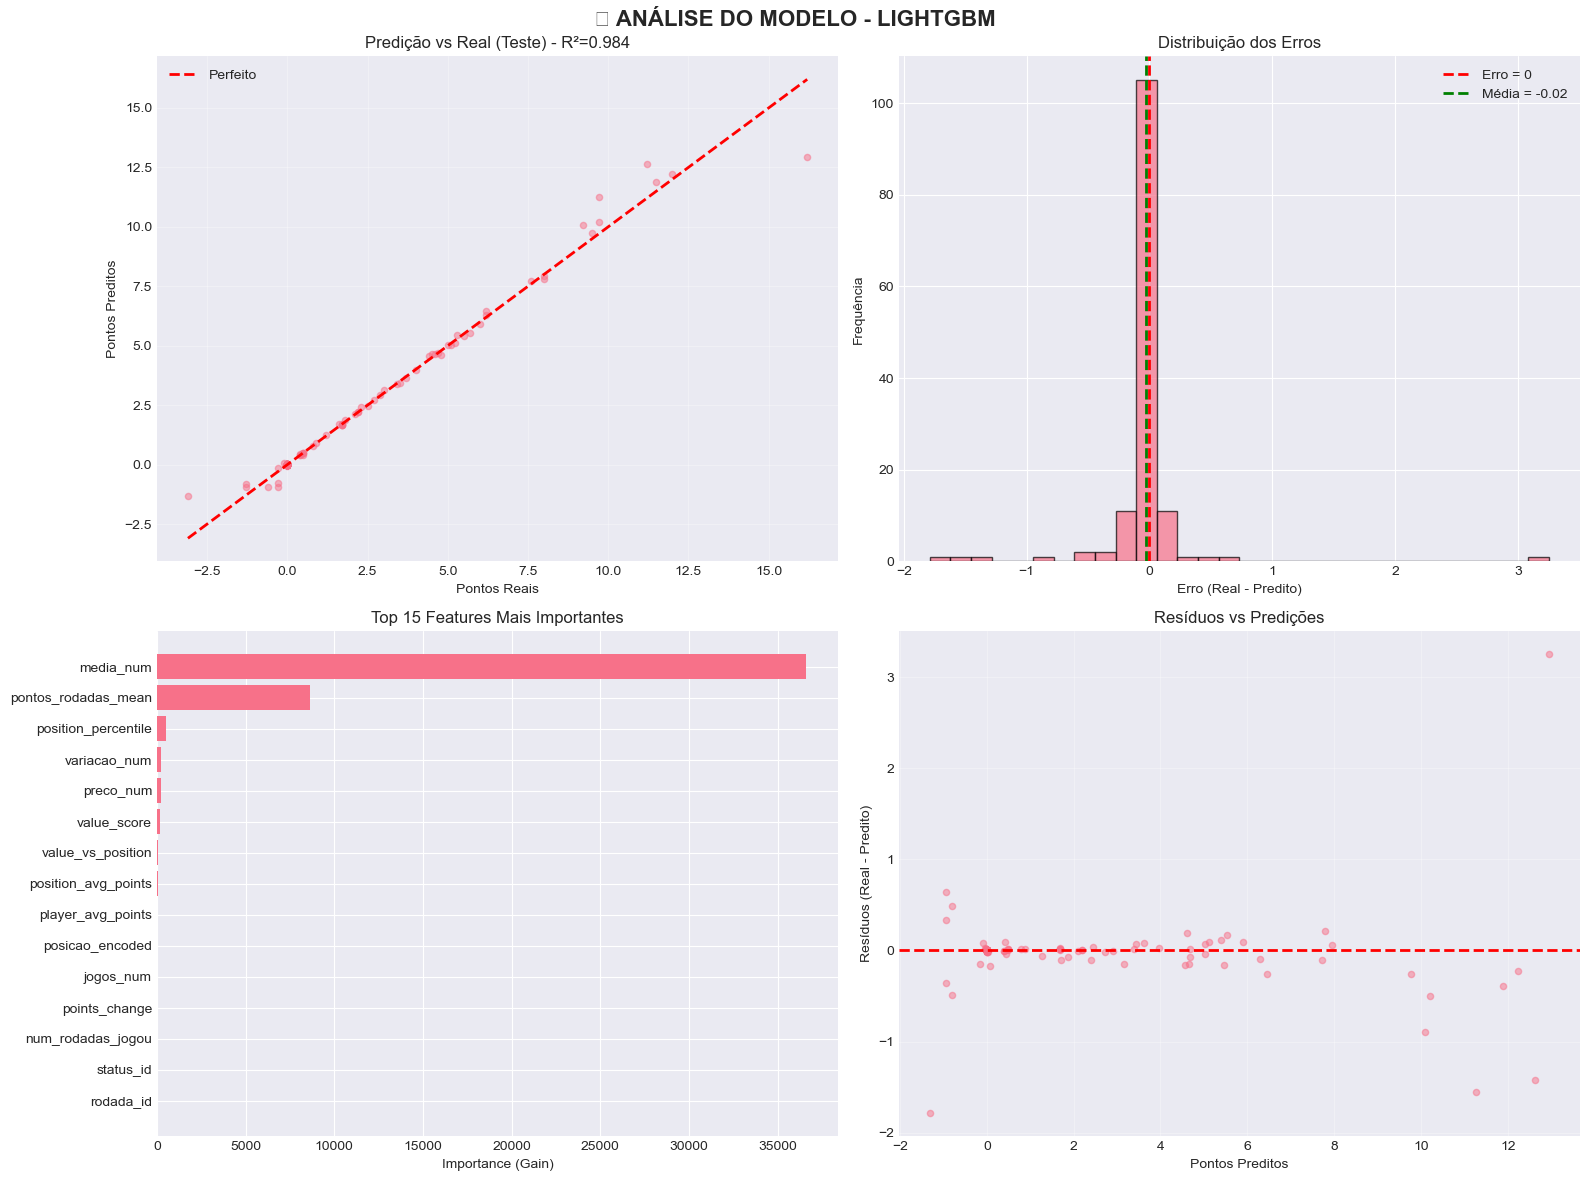


✅ Visualizações geradas!


In [7]:
if model is not None:
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('📊 ANÁLISE DO MODELO - LIGHTGBM', fontsize=16, fontweight='bold')
    
    # 1. Predicted vs Actual (Teste)
    axes[0,0].scatter(y_test, y_pred_test, alpha=0.5, s=20)
    axes[0,0].plot([y_test.min(), y_test.max()], 
                   [y_test.min(), y_test.max()], 
                   'r--', lw=2, label='Perfeito')
    axes[0,0].set_xlabel('Pontos Reais')
    axes[0,0].set_ylabel('Pontos Preditos')
    axes[0,0].set_title(f'Predição vs Real (Teste) - R²={r2_test:.3f}')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. Distribuição dos erros
    errors = y_test - y_pred_test
    axes[0,1].hist(errors, bins=30, edgecolor='black', alpha=0.7)
    axes[0,1].axvline(0, color='red', linestyle='--', linewidth=2, label='Erro = 0')
    axes[0,1].axvline(errors.mean(), color='green', linestyle='--', 
                     linewidth=2, label=f'Média = {errors.mean():.2f}')
    axes[0,1].set_xlabel('Erro (Real - Predito)')
    axes[0,1].set_ylabel('Frequência')
    axes[0,1].set_title('Distribuição dos Erros')
    axes[0,1].legend()
    
    # 3. Feature Importance (Top 15)
    importance = model.feature_importance(importance_type='gain')
    feature_names = X_train.columns
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False).head(15)
    
    axes[1,0].barh(importance_df['feature'], importance_df['importance'])
    axes[1,0].set_xlabel('Importance (Gain)')
    axes[1,0].set_title('Top 15 Features Mais Importantes')
    axes[1,0].invert_yaxis()
    
    # 4. Resíduos vs Predições
    axes[1,1].scatter(y_pred_test, errors, alpha=0.5, s=20)
    axes[1,1].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[1,1].set_xlabel('Pontos Preditos')
    axes[1,1].set_ylabel('Resíduos (Real - Predito)')
    axes[1,1].set_title('Resíduos vs Predições')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Visualizações geradas!")

else:
    print("❌ Sem modelo para visualizar!")

---
## 🔍 7. FEATURE IMPORTANCE

In [8]:
if model is not None:
    
    print("="*70)
    print(" "*20 + "🔍 FEATURE IMPORTANCE")
    print("="*70 + "\n")
    
    # Top 20 features
    importance = model.feature_importance(importance_type='gain')
    feature_names = X_train.columns
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance,
        'importance_pct': (importance / importance.sum() * 100)
    }).sort_values('importance', ascending=False)
    
    print("📊 TOP 20 FEATURES MAIS IMPORTANTES:\n")
    print(importance_df.head(20).to_string(index=False))
    
    print(f"\n💡 INSIGHTS:")
    top3 = importance_df.head(3)
    print(f"   As 3 features mais importantes explicam {top3['importance_pct'].sum():.1f}% do modelo")
    print(f"   Feature #1: {top3.iloc[0]['feature']} ({top3.iloc[0]['importance_pct']:.1f}%)")
    
    print("\n" + "="*70)

else:
    print("❌ Sem modelo!")

                    🔍 FEATURE IMPORTANCE

📊 TOP 20 FEATURES MAIS IMPORTANTES:

            feature   importance  importance_pct
          media_num 36585.981230       78.680489
pontos_rodadas_mean  8621.731469       18.541584
position_percentile   489.034408        1.051700
       variacao_num   244.312775        0.525410
          preco_num   241.256302        0.518837
        value_score   172.350714        0.370651
  value_vs_position    73.739453        0.158581
position_avg_points    31.126339        0.066939
  player_avg_points    16.645551        0.035797
    posicao_encoded     9.892916        0.021275
          jogos_num     8.988605        0.019331
      points_change     3.013743        0.006481
  num_rodadas_jogou     1.039420        0.002235
          status_id     0.319943        0.000688
          rodada_id     0.000000        0.000000
 pontos_rodadas_std     0.000000        0.000000
 player_games_count     0.000000        0.000000
 player_consistency     0.000000       

---
## 💾 8. SALVAR MODELO

In [9]:
if model is not None:
    
    print("="*70)
    print(" "*20 + "💾 SALVANDO MODELO")
    print("="*70 + "\n")
    
    # Criar diretório
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    
    # Salvar modelo
    model_path = MODELS_DIR / 'lightgbm_pontos.txt'
    model.save_model(str(model_path))
    
    print(f"✅ Modelo salvo: {model_path}")
    
    # Salvar métricas
    metrics = {
        'mae_train': mae_train,
        'rmse_train': rmse_train,
        'r2_train': r2_train,
        'mae_test': mae_test,
        'rmse_test': rmse_test,
        'r2_test': r2_test,
        'best_iteration': model.best_iteration,
        'num_features': len(X_train.columns),
        'train_size': len(X_train),
        'test_size': len(X_test)
    }
    
    import json
    metrics_path = MODELS_DIR / 'metrics.json'
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=2)
    
    print(f"✅ Métricas salvas: {metrics_path}")
    
    # Salvar feature importance
    importance_path = MODELS_DIR / 'feature_importance.csv'
    importance_df.to_csv(importance_path, index=False)
    
    print(f"✅ Feature importance: {importance_path}")
    
    logger.info(f"Modelo salvo: MAE={mae_test:.4f}, R2={r2_test:.4f}")
    
    print("\n" + "="*70)

else:
    print("❌ Sem modelo para salvar!")

                    💾 SALVANDO MODELO

✅ Modelo salvo: D:\football analytics project\models\lightgbm_pontos.txt
✅ Métricas salvas: D:\football analytics project\models\metrics.json
✅ Feature importance: D:\football analytics project\models\feature_importance.csv
2026-02-06 10:40:18 | ml | INFO | Modelo salvo: MAE=0.1179, R2=0.9844



---
## 📋 9. RESUMO FINAL

In [10]:
print("\n" + "="*70)
print(" "*10 + "🎉 NOTEBOOK 06 - MACHINE LEARNING CONCLUÍDO!")
print("="*70 + "\n")

if model is not None:
    print("📊 RESUMO DO MODELO:\n")
    print(f"✅ Algoritmo: LightGBM")
    print(f"✅ Features: {len(X_train.columns)}")
    print(f"✅ Treino: {len(X_train):,} registros")
    print(f"✅ Teste: {len(X_test):,} registros")
    print(f"✅ Iterações: {model.best_iteration}")
    
    print(f"\n📊 PERFORMANCE (TESTE):")
    print(f"   MAE:  {mae_test:.4f} (erro médio absoluto)")
    print(f"   RMSE: {rmse_test:.4f}")
    print(f"   R²:   {r2_test:.4f} ({r2_test*100:.1f}% da variância explicada)")
    
    print(f"\n💡 EM TERMOS PRÁTICOS:")
    print(f"   O modelo erra em média {mae_test:.2f} pontos")
    print(f"   Exemplo: Se prever 10 pontos, o real estará entre {10-mae_test:.1f} e {10+mae_test:.1f}")
    
    print(f"\n📁 Arquivos salvos:")
    print(f"   📂 lightgbm_pontos.txt (modelo)")
    print(f"   📂 metrics.json (métricas)")
    print(f"   📂 feature_importance.csv (importância)")
    
    print(f"\n🎯 PRÓXIMO PASSO:")
    print(f"   Dashboard Power BI / Tableau")

print("\n" + "="*70)

logger.info("Notebook 06 - Machine Learning concluído")


          🎉 NOTEBOOK 06 - MACHINE LEARNING CONCLUÍDO!

📊 RESUMO DO MODELO:

✅ Algoritmo: LightGBM
✅ Features: 19
✅ Treino: 553 registros
✅ Teste: 139 registros
✅ Iterações: 132

📊 PERFORMANCE (TESTE):
   MAE:  0.1179 (erro médio absoluto)
   RMSE: 0.3901
   R²:   0.9844 (98.4% da variância explicada)

💡 EM TERMOS PRÁTICOS:
   O modelo erra em média 0.12 pontos
   Exemplo: Se prever 10 pontos, o real estará entre 9.9 e 10.1

📁 Arquivos salvos:
   📂 lightgbm_pontos.txt (modelo)
   📂 metrics.json (métricas)
   📂 feature_importance.csv (importância)

🎯 PRÓXIMO PASSO:
   Dashboard Power BI / Tableau

2026-02-06 10:40:18 | ml | INFO | Notebook 06 - Machine Learning concluído
